In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.shape

(1338, 7)

In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
df['sex'] = df['sex'].map({"female": 1, "male": 0})
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [9]:
df.drop_duplicates(inplace=True)

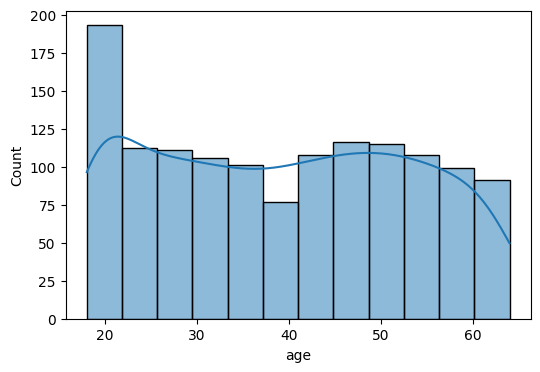

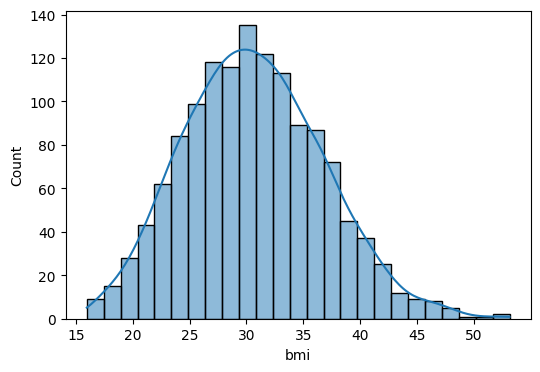

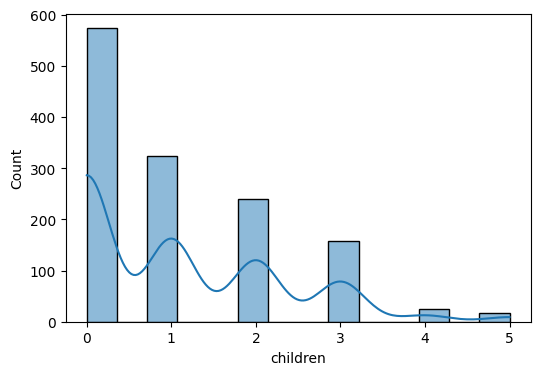

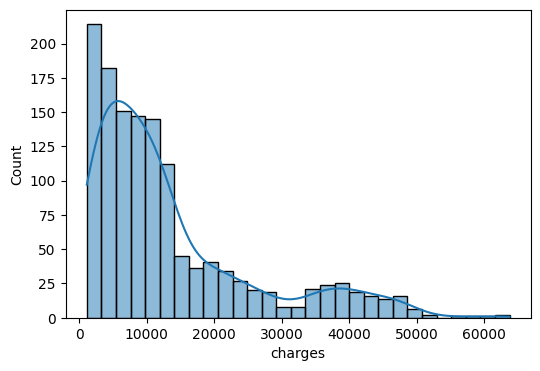

In [10]:
myColumns = ['age', 'bmi', 'children', 'charges']
for col in myColumns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

<Axes: xlabel='children', ylabel='count'>

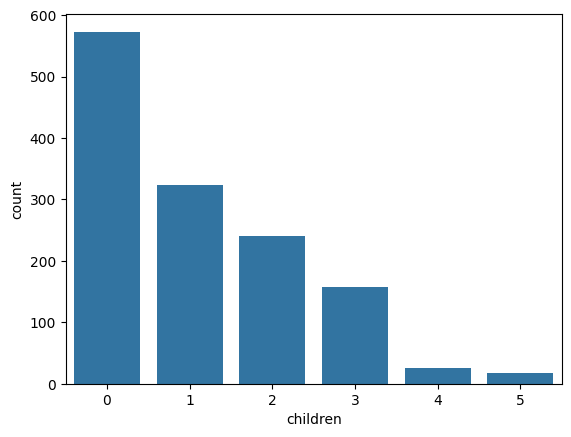

In [11]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

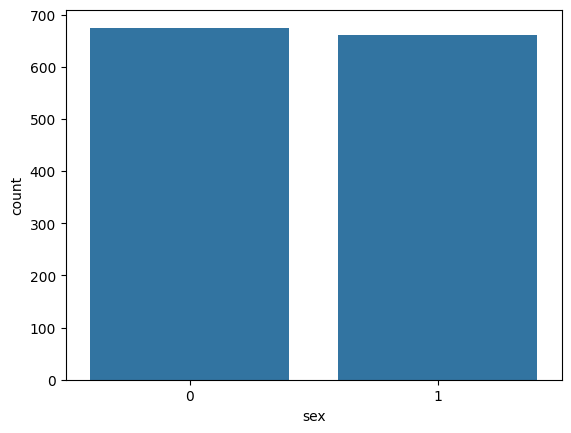

In [12]:
sns.countplot(x=df['sex'])

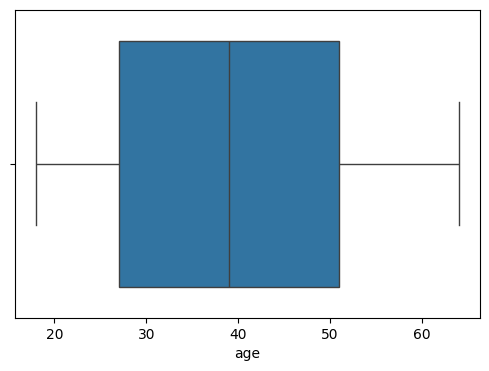

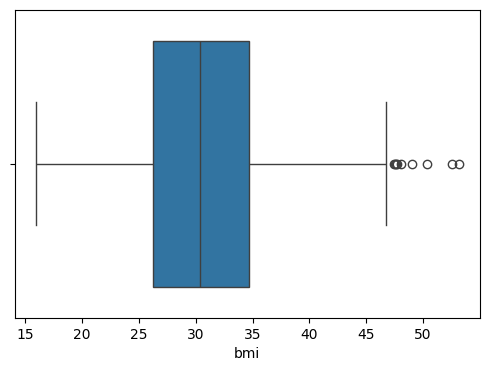

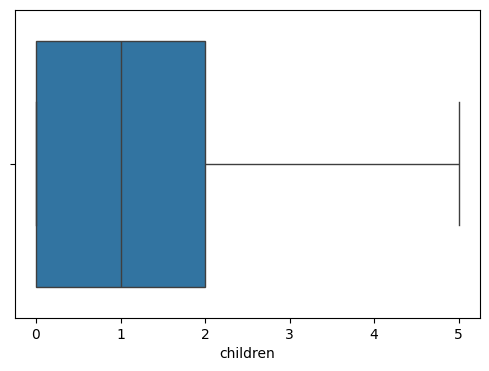

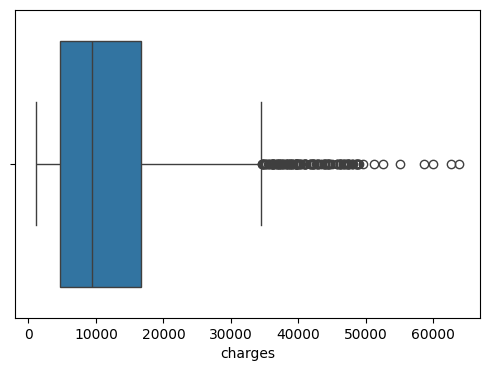

In [13]:
numeric_data = ['age', 'bmi', 'children', 'charges']
for col in numeric_data:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

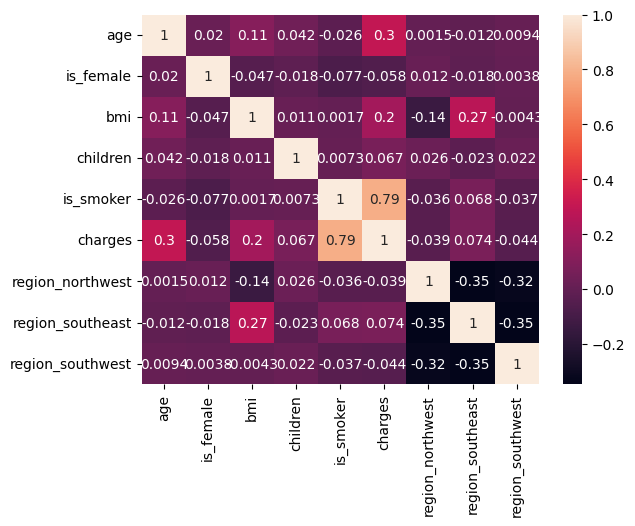

In [40]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [15]:
df['smoker'] = df['smoker'].map({"yes":1, "no":0})
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [16]:
df.rename(columns={"sex": "is_female", "smoker": "is_smoker"},
          inplace=True)

In [17]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [18]:
df_cleaned = pd.get_dummies(df,columns=['region'], drop_first=True)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False
1334,18,1,31.920,0,0,2205.98080,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,True


In [19]:
df = df_cleaned.astype(int)
df

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


<Axes: xlabel='bmi', ylabel='Count'>

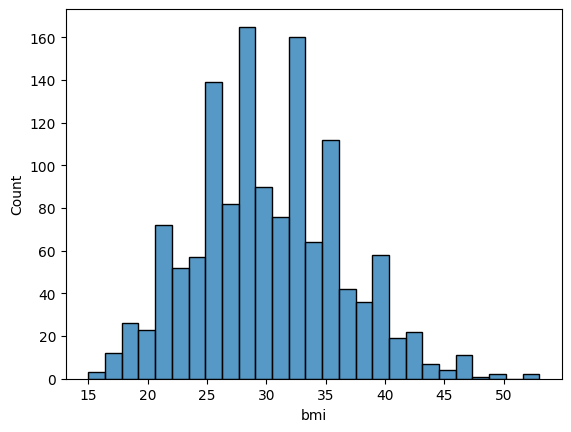

In [20]:
sns.histplot(df['bmi'])

In [21]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'],labels=['Underweight', 'Healthy', 
               'Overweight', 'Obese'],
          bins=[0,18.5,24.9,29.9,float('inf')],
      )
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,Overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,Obese
2,28,0,33.000,3,0,4449.46200,False,True,False,Obese
3,33,0,22.705,0,0,21984.47061,True,False,False,Healthy
4,32,0,28.880,0,0,3866.85520,True,False,False,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,Obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,Obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,Obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,Overweight


In [22]:
df_cleaned = pd.get_dummies(df_cleaned, 
               columns=['bmi_category'], drop_first=True)

In [23]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Healthy', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [24]:
df_cleaned = df_cleaned.astype(int)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Healthy,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [26]:
cols = ['age', 'bmi', 'children']
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Healthy,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X = df_cleaned.drop('charges', axis=1) #Input Feature
y = df_cleaned['charges'] #Output Feature

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
#Using Stochaistic Gradient Descent
#Instead of Entire batch use 1 example at a time
from sklearn.linear_model import SGDRegressor
sgd_model = SGDRegressor()
sgd_model.fit(X_train, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [33]:
#Performance Metrics
y_pred = model.predict(X_test)
y_pred

array([ 8166.78502481,  5258.38131296, 14497.99789106, 32423.6640176 ,
        8891.26581447, 13244.63457082, 30592.05118176,   979.84902293,
       11114.85682058, 10108.52380939, 10622.44251544, 32202.41254134,
       31975.49437307, 15697.09485972, 10645.35025208,  8303.83848414,
        5209.89541151, 32402.5675715 ,  2919.305424  ,  3980.50684962,
        4747.32918081, 29354.63599137, 13695.56304609, 29346.00605159,
       31419.5514214 ,  6326.29710096, 34873.7723571 , 37501.87867079,
       12910.61613546, 14641.39890665,  8014.78112639, 12948.46999436,
         435.70439017, 11129.53428269, 37304.88988202, 12975.93018524,
        3578.01505238,  4454.36647644, 31336.0564352 ,  8087.5739297 ,
        6438.55737161, 30726.84991053, 35211.61181082, 13512.72092791,
        7852.72704398,  2842.21462578,  5533.412083  ,  7399.45168833,
        3661.69324597, 10381.31072588,  7802.6750964 , 10815.24872451,
       30889.18486887,  4696.70778781, 11331.12137502, 11452.69627431,
      

In [34]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, r2_score
r2_scored = r2_score(y_test, y_pred)
r2_scored

0.8026400252129843

In [36]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2_scored) * (n - 1))/(n - p - 1)
adjusted_r2

0.7941597137963547

In [37]:
y_pred_sgd = sgd_model.predict(X_test)
y_pred_sgd

array([ 8044.65708115,  5227.1902128 , 14522.82715298, 32380.60903641,
        8958.72417485, 13300.71622168, 30378.00264142,  1045.06809135,
       11131.94207876, 10159.57710029, 10659.26872964, 32213.00321113,
       31746.78661465, 15858.11099536, 10515.93178121,  8354.95652062,
        5213.97632933, 32382.89810864,  2970.76817074,  4032.55878352,
        4740.62540477, 29178.42548979, 13805.7995702 , 29351.47685115,
       31400.32830379,  6311.6870972 , 34900.23351614, 37453.72198674,
       12677.01157088, 14470.85529133,  7801.60316795, 13013.77248271,
         493.1282694 , 11177.64174275, 37452.67764212, 12981.65056222,
        3579.4255828 ,  4429.83654292, 31311.48071752,  8128.0782132 ,
        6339.47010789, 30484.90439606, 35175.03914086, 13326.47888911,
        7839.98206112,  2847.05217123,  5448.0947011 ,  7455.61803162,
        3665.78228232, 10363.41474133,  7779.23905414, 10780.54174507,
       30652.69666408,  4708.11736515, 11358.82038618, 11406.74770349,
      

In [38]:
r2_scored_sgd = r2_score(y_test, y_pred_sgd)
r2_scored_sgd

0.803565804597597

In [39]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2_scored_sgd) * (n - 1))/(n - p - 1)
adjusted_r2

0.7951252727639